In [21]:
!pip install te2rules
!pip install lime

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('/content/cardio_data_cleaned(IQR).csv')
X = df.drop('cardio', axis=1)
y = df['cardio']
feature_names = X.columns.tolist()

X = X.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

***Train the model on the high risk***

In [23]:
from xgboost import XGBClassifier
model_high = XGBClassifier(
  n_estimators=50,
  max_depth=4,
  learning_rate=0.1,
  random_state=42
)

model_high.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_train_pred = model_high.predict(X_train)
y_test_pred = model_high.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
print(f"Accuracy of the test data : {accuracy:.4f}")
accuracy = accuracy_score(y_train, y_train_pred)
print(f"Accuracy of the train data : {accuracy:.4f}")


Accuracy of the test data : 0.7213
Accuracy of the train data : 0.7173


In [25]:
tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, y_test_pred).ravel()

sensitivity_test = tp_test / (tp_test + fn_test) * 100
specificity_test = tn_test / (tn_test + fp_test) * 100
print(f"Sensitivity of the test data : {sensitivity_test:.4f}%")
print(f"Specificity of the test data : {specificity_test:.4f}%")
tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, y_train_pred).ravel()
sensitivity_train = tp_train / (tp_train + fn_train) * 100
specificity_train = tn_train / (tn_train + fp_train) * 100
print(f"Sensitivity of the train data : {sensitivity_train:.4f}%")
print(f"Specificity of the train data : {specificity_train:.4f}%")

Sensitivity of the test data : 67.9096%
Specificity of the test data : 76.2039%
Sensitivity of the train data : 67.4173%
Specificity of the train data : 75.9692%


**TE2Rules for high risk**

In [26]:
from te2rules.explainer import ModelExplainer
explainer_high = ModelExplainer(
    model=model_high,
    feature_names=feature_names
)

rules = explainer_high.explain(X_test,y_test_pred)

100%|██████████| 13622/13622 [00:11<00:00, 1176.10it/s]


In [27]:
print("Extracted high risk Rules:")
for rule in rules[:5]:
    print(rule)

Extracted high risk Rules:
MAP >= 3.0
MAP < 3.0 & age >= 4.0 & cholesterol >= 3.0
BMI >= 2.0 & active < 1.0 & age >= 5.0
cholesterol >= 3.0 & gluc < 3.0
BMI >= 2.0 & active >= 1.0 & age >= 5.0 & cholesterol >= 2.0


In [28]:
(fidelity, fidelity_pos, fidelity_neg) = explainer_high.get_fidelity()
print("Fidelity:", fidelity)
print("Fidelity Positive:", fidelity_pos)
print("Fidelity Negative:", fidelity_neg)

Fidelity: 0.9770145591192987
Fidelity Positive: 0.9999999998826291
Fidelity Negative: 0.9578731305876382


**Low risk model**

In [29]:
y_train_low = 1 - y_train
y_test_low = 1 - y_test
model_low = XGBClassifier(n_estimators=50, max_depth=4, random_state=42)
model_low.fit(X_train, y_train_low)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [30]:
y_train_pred_low = model_low.predict(X_train)
y_test_pred_low = model_low.predict(X_test)

accuracy = accuracy_score(y_test_low, y_test_pred_low)
print(f"Accuracy of the test data : {accuracy:.4f}")
accuracy = accuracy_score(y_train, y_train_pred)
print(f"Accuracy of the train data : {accuracy:.4f}")


Accuracy of the test data : 0.7205
Accuracy of the train data : 0.7173


**TE2Rules for Low Risk model**

In [40]:
explainer_low = ModelExplainer(model=model_low, feature_names=feature_names)
rules_low = explainer_low.explain(X_test, y_test_pred_low)

100%|██████████| 144658/144658 [00:41<00:00, 3466.91it/s]


In [41]:
print("Extracted low risk Rules:")
for rule in rules_low[:5]:
    print(rule)

Extracted low risk Rules:
MAP < 3.0 & age < 5.0 & cholesterol < 2.0
BMI >= 2.0 & MAP < 3.0 & active >= 1.0 & cholesterol < 3.0
MAP < 3.0 & age < 4.0
MAP < 4.0 & active >= 1.0 & age < 5.0 & cholesterol < 2.0 & smoke >= 1.0
BMI < 2.0 & MAP < 3.0 & age >= 2.0


In [42]:
(fidelity, fidelity_pos, fidelity_neg) = explainer_low.get_fidelity()
print("Fidelity:", fidelity)
print("Fidelity Positive:", fidelity_pos)
print("Fidelity Negative:", fidelity_neg)

Fidelity: 0.9636286063715398
Fidelity Positive: 0.9999999999006359
Fidelity Negative: 0.9214918843189257


**Lime**

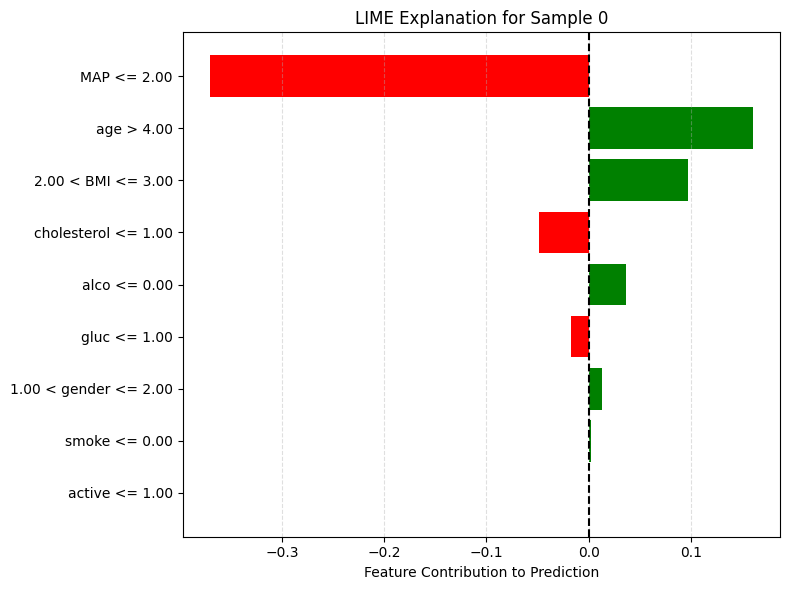

In [34]:
import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(X_train,feature_names=feature_names,mode = 'classification' , class_names=['No cardio','Cardio'])
explanation = explainer.explain_instance(X_test[0],model_high.predict_proba,num_features=10)
exp_list = explanation.as_list(label=1)[::-1]
features = [item[0] for item in exp_list]
weights = [item[1] for item in exp_list]

plt.figure(figsize=(8, 6))
bars = plt.barh(features, weights, color=['green' if w > 0 else 'red' for w in weights])
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel("Feature Contribution to Prediction")
plt.title(f"LIME Explanation for Sample {0}", loc='center')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()


Surrotage model

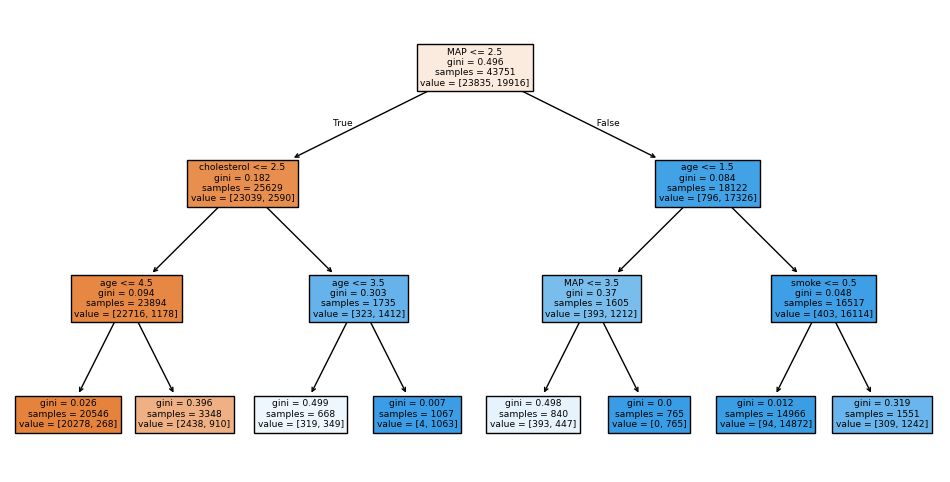

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score
from sklearn import tree
surrotage = DecisionTreeClassifier(max_depth = 3)
rf_preds = model_high.predict(X_train)
surrotage.fit(X_train,rf_preds)
plt.figure(figsize=(12,6))
tree.plot_tree(surrotage,feature_names = feature_names,filled = True)
plt.show()